# **Cycloergometer Testing**



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
student_info = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/subject-info.csv')

In [ ]:
test_measure = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test_measure.csv')

In [ ]:
student_info.head()

,ID,age,Weight,Height,P_vt1,P_vt2,sport
0,1,15,53.7,161,50,140,fencing
1,2,15,56.2,162,80,127,fencing
2,3,16,89.9,191,155,300,fencing
3,4,16,76.5,180,215,275,fencing
4,5,17,76.4,186,110,172,fencing


In [ ]:
test_measure.head()

,ID,time,RR,VO2,power
0,1,-130.840,672.0,0.302008,0
1,1,-130.168,672.0,0.302008,0
2,1,-129.536,632.0,0.301336,0
3,1,-128.824,712.0,0.301336,0
4,1,-127.948,876.0,0.301336,0


## **Abstract**

This study investigates physiological responses of young athletes to exercise using cycloergometer testing data, aiming to deepen our understanding of cardiovascular dynamics during physical activity. A cycloergometer is basically just a bike that is capable of measuring the power output generated from the user. Such insights are crucial for optimizing training regimens and enhancing athletic performance and health. The primary goal was to analyze correlations between factors like BMI, weight, age, and sport with heart rate and power output, and to develop predictive models for these physiological metrics. Data preprocessing involved handling missing values, encoding categorical variables, and removing outliers using the IQR method. Linear regression models were then developed to predict both power output and heart rate from various athletic and test parameters. The analysis revealed a positive correlation between weight and power output, while BMI and age showed slight negative correlations with heart rate. The predictive models achieved an R-squared of approximately 0.73 for power output and a strong 0.97 for heart rate, indicating good predictive capability. The findings contribute to a better understanding of athletic physiology, which can inform personalized training programs and potentially lead to improved health outcomes and performance strategies for young athletes.

##### **Research Goals**


 - Find how BMI effects an athletes heart rate during excercise.


- Determine if there is a correlation to Weight and power output.

- Does age have a correlation to the athletes heart rate?

- Does the sport an athlete plays impact their efficiency in generating power over time?

- Create a model to predict an athlets power output and heart rate.

This study is important because it will help us further our understanding of how the heart works during excercise.

##**Introduction of Data Set & Variables**

#### **Bacground of Data Set**

The data sets contain information on young athletes aged 15-18, and these athletes had cardiac and respitory testing done in 2017-2018. These athletes basic information can be found in the student_info data set. For example, the variables of the data set include height, age, weight, sport, and the power outputs (P_vt1 & P_vt2). The data in test_measure is has far more observations than student_info. The data set contains one line in test_measure for each beat measure of all 18 effort tests. The variables for the data set includes the time of each test, the heart rate R-wave to R-wave interval (RR), oxygen consumption (VO2 in mL/min), and power in cycloergometer (in watts). In student info, the shape is 18 rows and 7 columns. In test measure, the shape is 52062 rows and 5 columns.
https://physionet.org/content/actes-cycloergometer-exercise/1.0.0/

In [ ]:
student_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      18 non-null     int64  
 1   age     18 non-null     int64  
 2   Weight  18 non-null     float64
 3   Height  18 non-null     int64  
 4   P_vt1   18 non-null     int64  
 5   P_vt2   18 non-null     int64  
 6   sport   18 non-null     object 
dtypes: float64(1), int64(5), object(1)
memory usage: 1.1+ KB


In [ ]:
student_info.shape # the shape shows us that there are 7 variables in this data set

(18, 7)

In [ ]:
students = student_info.shape[0]
print(f"There were {students} students in the dataset.")

There were 18 students in the dataset.


In [ ]:
students = student_info.shape[1]
print(f"There were {students} variables in the dataset.")

There were 7 variables in the dataset.


In [ ]:
student_info.dtypes

,0
ID,int64
age,int64
Weight,float64
Height,int64
P_vt1,int64
P_vt2,int64
sport,object


In [ ]:
test_measure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52062 entries, 0 to 52061
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      52062 non-null  int64  
 1   time    52062 non-null  float64
 2   RR      50914 non-null  float64
 3   VO2     52062 non-null  float64
 4   power   52062 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 2.0 MB


In [ ]:
test_measure.shape #The shape shows us that there are 5 variables in the data set.

(52062, 5)

In [ ]:
recorded_tests = test_measure.shape[0]
print(f"There were {recorded_tests} beat measurements in the dataset.")

There were 52062 beat measurements in the dataset.


In [ ]:
recorded_tests = test_measure.shape[1]
print(f"There were {recorded_tests} variables recorded in the dataset.")

There were 5 variables recorded in the dataset.


In [ ]:
test_measure.dtypes

,0
ID,int64
time,float64
RR,float64
VO2,float64
power,int64


##**Data Cleaning & Preprocessing**

In [ ]:
student_info.isnull().sum()

,0
ID,0
age,0
Weight,0
Height,0
P_vt1,0
P_vt2,0
sport,0


In [ ]:
test_measure.isnull().sum()

,0
ID,0
time,0
RR,1148
VO2,0
power,0


##### **Handling Missing Values**

In [ ]:
test_measure['RR'] = test_measure['RR'].fillna(test_measure['RR'].mean())
test_measure.isnull().sum()

,0
ID,0
time,0
RR,0
VO2,0
power,0


##### **Converting Categorical Variables**

In [ ]:
# Create a mapping dictionary
sports_mapping = {'fencing': 1, 'triathlon': 2, 'kayak': 3}

# Replace the original 'sport' column with encoded values
student_info['sport'] = student_info['sport'].map(sports_mapping)

# Display the result
display(student_info.head())

,ID,age,Weight,Height,P_vt1,P_vt2,sport
0,1,15,53.7,161,50,140,1
1,2,15,56.2,162,80,127,1
2,3,16,89.9,191,155,300,1
3,4,16,76.5,180,215,275,1
4,5,17,76.4,186,110,172,1


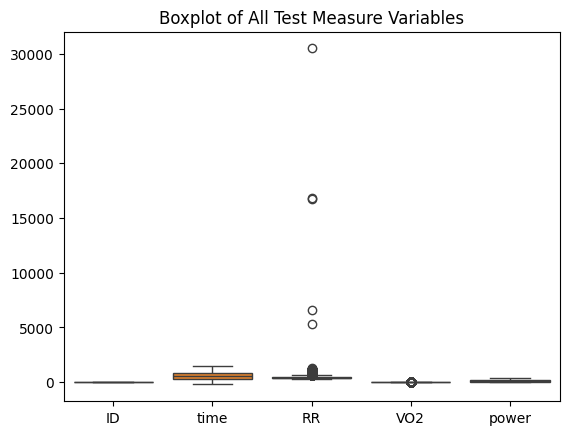

In [ ]:
# look at outliers
plt.title('Boxplot of All Test Measure Variables')
sns.boxplot(data = test_measure)
plt.show()

The boxplot titled reveals a significant presence of outliers, particularly for the 'RR' variable. The distribution of 'RR' shows numerous data points extending far beyond the whiskers, indicating extreme values that could skew further analysis. 'VO2' and 'power' also exhibit some outliers, though less pronounced than 'RR'. The 'time' variable appears relatively clean with fewer extreme values.

In [ ]:
# Identify and remove outliers using the IQR method for specified columns
columns_to_clean = ['time', 'RR', 'VO2', 'power']

for col in columns_to_clean:
    Q1 = test_measure[col].quantile(0.25)
    Q3 = test_measure[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    test_measure = test_measure[(test_measure[col] >= lower_bound) & (test_measure[col] <= upper_bound)]

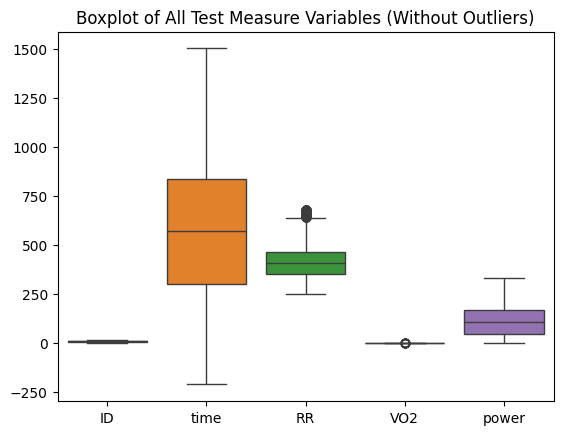

In [ ]:
plt.title('Boxplot of All Test Measure Variables (Without Outliers)')
sns.boxplot(data = test_measure)
plt.show()

The boxplot clearly shows the effect of the IQR method in removing extreme values. Compared to the previous boxplot, the distributions for 'RR', 'VO2', and 'power' are now much tighter, with significantly shorter whiskers and a more concentrated interquartile range. This indicates that the outlier removal process successfully eliminated the data points that were previously skewing the representation, particularly for 'RR' where many extreme outliers were observed. The 'time' variable also shows a more contained distribution, suggesting a more accurate representation of the core data without the influence of far-reaching anomalies.

In [ ]:
#creating a BMI variable
student_info['Height_m'] = student_info['Height'] / 100 #student height in meters
student_info['BMI'] = student_info['Weight'] / (student_info['Height_m']**2)

#creating a Hear_Rate variable
test_measure['Heart_Rate'] = 60000 / test_measure['RR']

In [ ]:
avg_hr_per_student = test_measure.groupby('ID')['Heart_Rate'].mean().reset_index()
bmi_hr_df = pd.merge(student_info[['ID', 'BMI']], avg_hr_per_student, on='ID', how='inner')

## **Visualizations**

### **BMI vs. Athlete's Heart Rate**

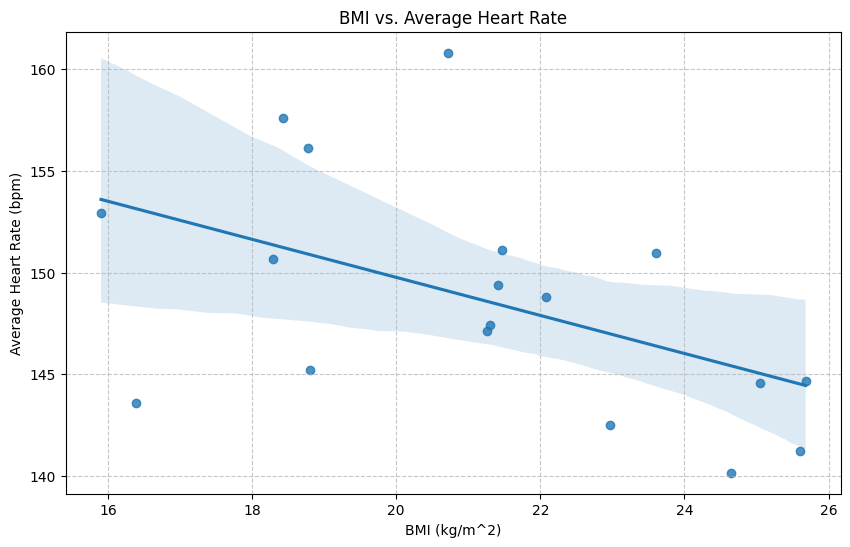

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=bmi_hr_df, x='BMI', y='Heart_Rate')
plt.title('BMI vs. Average Heart Rate')
plt.xlabel('BMI (kg/m^2)')
plt.ylabel('Average Heart Rate (bpm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The graph displays a slight negative correlation, indicated by the downward-sloping regression line. However, the data points are quite spread out, suggesting that while there's a trend, BMI alone may not be a strong predictor of average heart rate in this dataset.

### **Weight vs. Power Output**

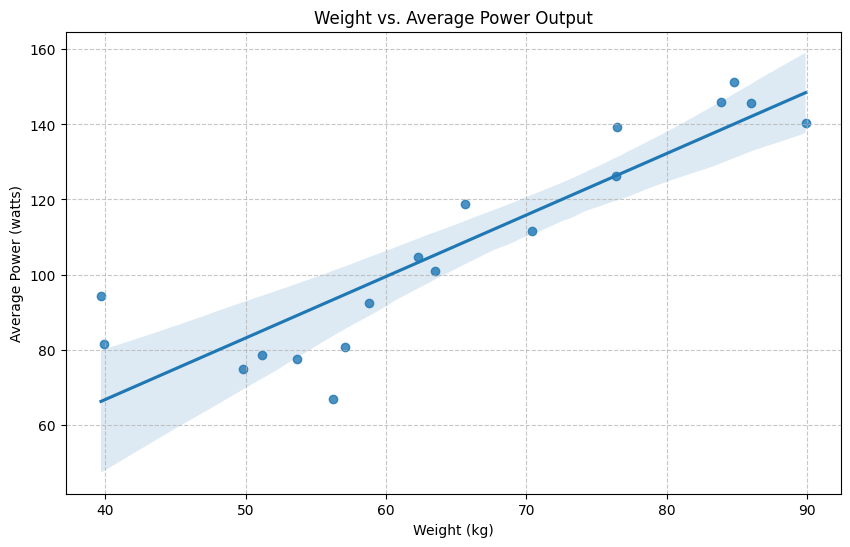

In [ ]:
avg_power_per_student = test_measure.groupby('ID')['power'].mean().reset_index()
weight_power_df = pd.merge(student_info[['ID', 'Weight']], avg_power_per_student, on='ID', how='inner')

plt.figure(figsize=(10, 6))
sns.regplot(data=weight_power_df, x='Weight', y='power')
plt.title('Weight vs. Average Power Output')
plt.xlabel('Weight (kg)')
plt.ylabel('Average Power (watts)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The graph shows a positive correlation between an athlete's weight and their average power output. The upward-sloping regression line suggests that as weight increases, the average power generated also tends to increase. This could imply that heavier athletes, potentially due to greater muscle mass, are capable of producing more power on the cycloergometer.

### **Age vs. Athlete's Heart Rate**

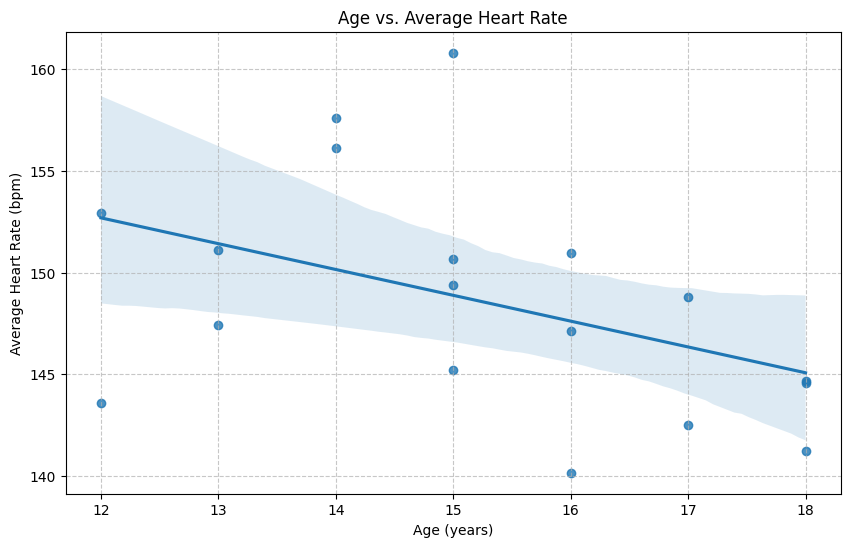

In [ ]:
age_hr_df = pd.merge(student_info[['ID', 'age']], avg_hr_per_student, on='ID', how='inner')

plt.figure(figsize=(10, 6))
sns.regplot(data=age_hr_df, x='age', y='Heart_Rate')
plt.title('Age vs. Average Heart Rate')
plt.xlabel('Age (years)')
plt.ylabel('Average Heart Rate (bpm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The graph shows a slightly negative correlation, similar to the BMI vs. Heart Rate graph. This indicates that as age increases, the average heart rate tends to slightly decrease, though the spread of data points suggests age alone may not be a strong predictor.

### **Sport vs. Power Efficiency**

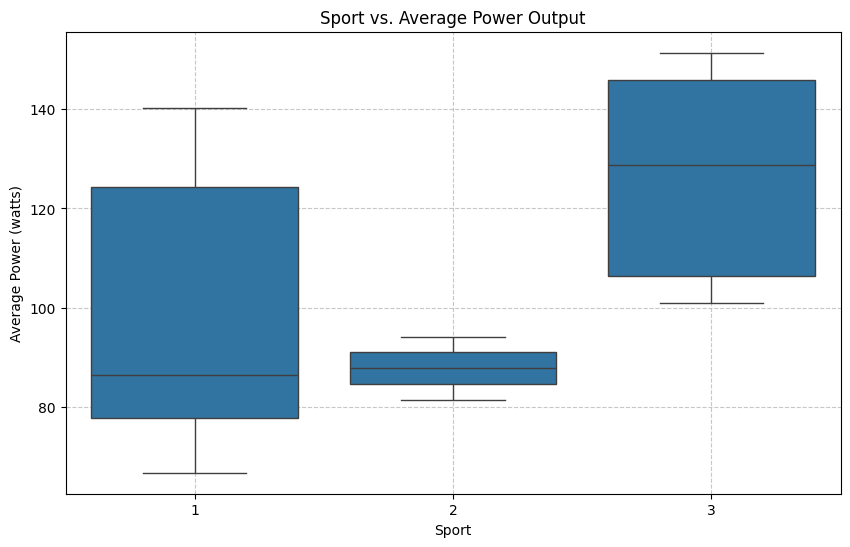

In [ ]:
sport_power_df = pd.merge(student_info[['ID', 'sport']], avg_power_per_student, on='ID', how='inner')

plt.figure(figsize=(10, 6))
sns.boxplot(data=sport_power_df, x='sport', y='power')
plt.title('Sport vs. Average Power Output')
plt.xlabel('Sport')
plt.ylabel('Average Power (watts)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

For this graph 1 = Fencing , 2 = Triathlon, 3 = Kayak. Kayak has the highest average power with fencing and triatholn having the same mean. This data isn't fair as there are uneven number of data for each sport with triathon only having 2 data points. This isn't enough data to have a conclusive answer without bias.

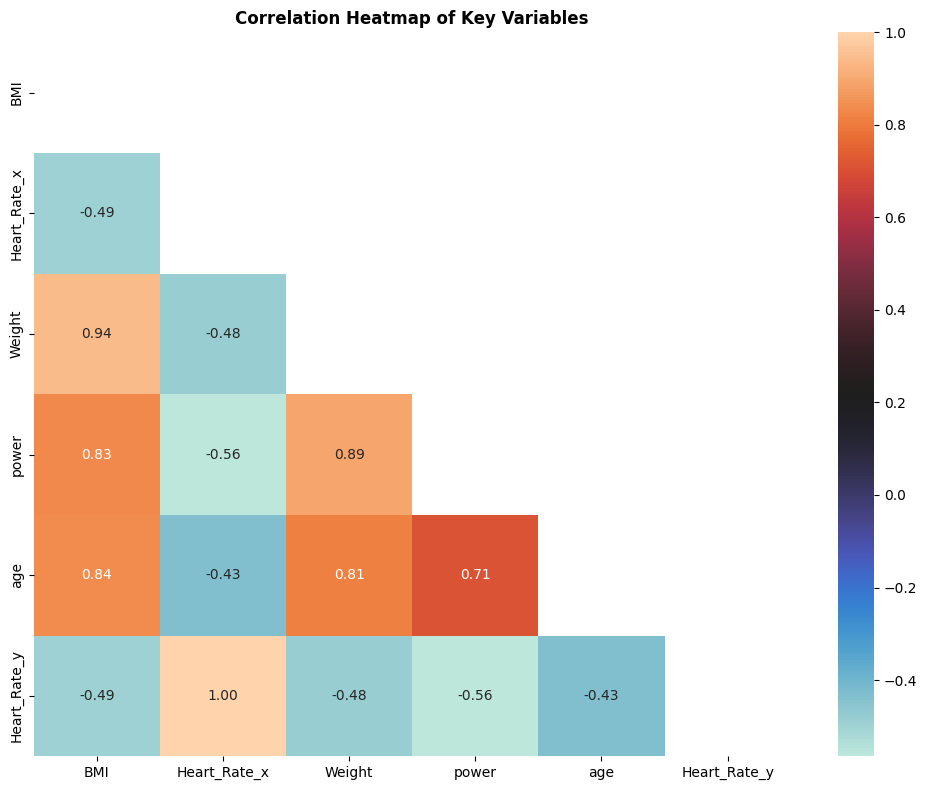

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))

temp = pd.merge(bmi_hr_df, weight_power_df, on='ID', how='inner')
corr_cols = pd.merge(temp, age_hr_df, on='ID', how='inner')
corr_cols = corr_cols.drop(columns = 'ID')
corr_matrix = corr_cols.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
# make into triangle

sns.heatmap(corr_matrix,
            mask = mask,
            annot=True, fmt='.2f', cmap='icefire')
plt.title('Correlation Heatmap of Key Variables', fontweight='bold')
plt.tight_layout()
plt.show()

The correlation heatmap reveals strong relationships between several key variables. Notably, there is a very high positive correlation between Weight and power output, suggesting that heavier athletes tend to produce more power. Conversely, Heart_Rate shows a moderate negative correlation with power and weight, indicating that higher weight and power output are associated with lower average heart rates.

##**Input Preparation and Normalization/Standardization**

### Preparing the dataset for modeling

In [ ]:
# Merge student_info with average power per student and average heart rate per student
# We need to make sure 'student_info' includes 'BMI' and encoded 'sport' if we want to use them as features
# Re-create student_info_encoded to include BMI for features

test_ml = test_measure.copy()
test_ml = pd.get_dummies(test_ml)

# Merge with average power output to get the first target variable
dataset = pd.merge(test_ml, student_info, on='ID', how='inner')
# Now merge with average heart rate to get the second target variable

#dataset = pd.merge(dataset, avg_hr_per_student, on='ID', how='inner')

display(dataset.head())

,ID,time,RR,VO2,power,Heart_Rate,age,Weight,Height,P_vt1,P_vt2,sport,Height_m,BMI
0,1,-130.840,672.0,0.302008,0,89.285714,15,53.7,161,50,140,1,1.61,20.716793
1,1,-130.168,672.0,0.302008,0,89.285714,15,53.7,161,50,140,1,1.61,20.716793
2,1,-129.536,632.0,0.301336,0,94.936709,15,53.7,161,50,140,1,1.61,20.716793
3,1,-109.280,672.0,0.310178,0,89.285714,15,53.7,161,50,140,1,1.61,20.716793
4,1,-104.280,660.0,0.329340,0,90.909091,15,53.7,161,50,140,1,1.61,20.716793


### Outlier Detection for Target Variable (Average Power)

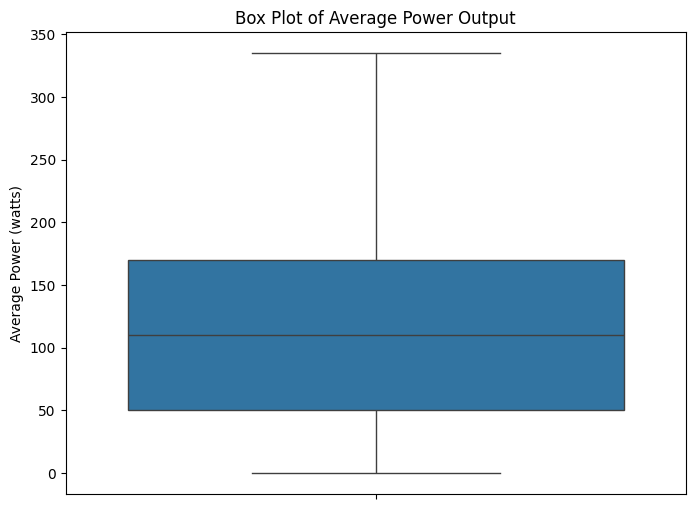

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=dataset['power'])
plt.title('Box Plot of Average Power Output')
plt.ylabel('Average Power (watts)')
plt.show()

# Calculate quartiles and IQR for outlier detection
Q1 = dataset['power'].quantile(0.25)
Q3 = dataset['power'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = dataset[(dataset['power'] < lower_bound) | (dataset['power'] > upper_bound)]

The box plot shows the distribution of power values. The box represents the interquartile range (IQR), with the median indicated by the line inside. The whiskers extend to the minimum and maximum values within 1.5 times the IQR, and any points beyond these whiskers are considered outliers, indicating some extreme power output values in the dataset.

### Defining Features (X) and Target (y), and Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
# We'll use age, Weight, Height, BMI, P_vt1, P_vt2, and one-hot encoded sport as features.
X = dataset.drop(columns = 'power')
y = dataset['power']

# Define features (X_hr) and target (y_hr) for Heart_Rate
X_hr = dataset.drop(columns=['Heart_Rate', 'sport'])
y_hr = dataset['Heart_Rate']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print(f"Features (X_hr) shape: {X_hr.shape}")
print(f"Target (y_hr) shape: {y_hr.shape}")

Features (X) shape: (48758, 13)
Target (y) shape: (48758,)
Features (X_hr) shape: (48758, 12)
Target (y_hr) shape: (48758,)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (39006, 13)
X_test shape: (9752, 13)
y_train shape: (39006,)
y_test shape: (9752,)


In [ ]:
# Split the data into training and testing sets for Heart_Rate
X_hr_train, X_hr_test, y_hr_train, y_hr_test = train_test_split(X_hr, y_hr,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"X_hr_train shape: {X_hr_train.shape}")
print(f"X_hr_test shape: {X_hr_test.shape}")
print(f"y_hr_train shape: {y_hr_train.shape}")
print(f"y_hr_test shape: {y_hr_test.shape}")

X_hr_train shape: (39006, 12)
X_hr_test shape: (9752, 12)
y_hr_train shape: (39006,)
y_hr_test shape: (9752,)


### Normalization/Standardization of Input Features (X)

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Convert scaled arrays back to DataFrames (optional, but good for inspection)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)


In [ ]:
# Initialize the StandardScaler for Heart_Rate features
scaler_hr = StandardScaler()

In [ ]:
# Fit the scaler on the training data and transform both training and testing data
X_hr_train_scaled = scaler_hr.fit_transform(X_hr_train)
X_hr_test_scaled = scaler_hr.transform(X_hr_test)

# Convert scaled arrays back to DataFrames for inspection (optional)
X_hr_train_scaled_df = pd.DataFrame(X_hr_train_scaled, columns=X_hr.columns, index=X_hr_train.index)
X_hr_test_scaled_df = pd.DataFrame(X_hr_test_scaled, columns=X_hr.columns, index=X_hr_test.index)

## **Model Building for Power**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_reg = LinearRegression()

### Training Model For Power

In [ ]:
linear_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
linear_reg.coef_

array([-48.8095204 , -13.64567752,  16.27361516,  80.19536494,
        22.27769081,   3.8791972 , -96.20682501,  25.3208483 ,
        12.81996714,  23.77820092,  41.41087274,  25.3208483 ,
       -12.98511549])

In [ ]:
linear_reg.intercept_

np.float64(112.80200481977128)

In [ ]:
y_test_pred = linear_reg.predict(X_test_scaled)

In [ ]:
y_test.head()

,power
6293,260
29042,0
44396,50
27165,155
39012,0


## **Model Building for Heart Rate**

### Training Model for Heart Rate

In [ ]:
linear_reg_hr = LinearRegression()
linear_reg_hr.fit(X_hr_train_scaled, y_hr_train)

LinearRegression()

In [ ]:
y_hr_test_pred = linear_reg_hr.predict(X_hr_test_scaled)

## **Performance Evaluation for Power**

In [ ]:
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                            r2_score,
                            mean_absolute_percentage_error)

In [ ]:
# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_test_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_test_pred)

# Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_test, y_test_pred)*100

# R-squared (R^2)
r_squared = r2_score(y_test, y_test_pred)

In [ ]:
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)
print("R-squared:", r_squared)

Mean Squared Error: 2021.7830902496044
Root Mean Squared Error: 44.96424235155758
Mean Absolute Error: 28.492494340055146
Mean Absolute Percentage Error: 4.909528963588671e+18
R-squared: 0.734431188795472


In [ ]:
y_test  = y_test.values.ravel()
y_test_pred = y_test_pred.ravel()

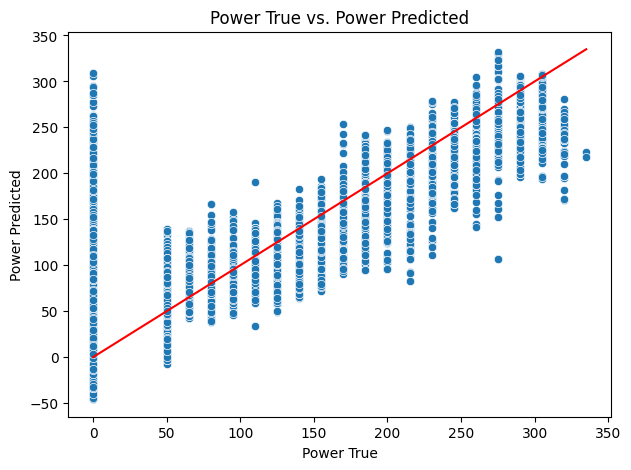

In [ ]:
plt.figure(figsize = (7,5))
sns.scatterplot(x = y_test,
                y = y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color = 'red')
plt.xlabel("Power True")
plt.ylabel('Power Predicted')
plt.title('Power True vs. Power Predicted')
plt.show()

Visual analysis of the 'Power True vs. Power Predicted' scatter plot revealed a generally linear trend, particularly at higher power outputs. However, the model struggled to differentiate between very low power values and zero, resulting in clustering near the origin. This limitation is likely influenced by the large number of zero-power entries in the training data, which may have reduced the model's ability to capture subtle variations in low-intensity efforts. The lack of predictability is why we created a new model targeting heart_rate.


### **Performance Evaluation for Heart Rate**

In [ ]:
# Mean Squared Error (MSE)
hr_mse = mean_squared_error(y_hr_test, y_hr_test_pred)

# Root Mean Squared Error (RMSE)
hr_rmse = np.sqrt(hr_mse)

# Mean Absolute Error (MAE)
hr_mae = mean_absolute_error(y_hr_test, y_hr_test_pred)

# Mean Absolute Percentage Error (MAPE)
hr_mape = mean_absolute_percentage_error(y_hr_test, y_hr_test_pred)*100

# R-squared (R^2)
hr_r_squared = r2_score(y_hr_test, y_hr_test_pred)

In [ ]:
print("Mean Squared Error:", hr_mse)
print("Root Mean Squared Error:", hr_rmse)
print("Mean Absolute Error:", hr_mae)
print("Mean Absolute Percentage Error:", hr_mape)
print("R-squared:", hr_r_squared)

Mean Squared Error: 21.411750627133962
Root Mean Squared Error: 4.627283287970811
Mean Absolute Error: 3.5951812772070593
Mean Absolute Percentage Error: 2.564797096835494
R-squared: 0.9663396499323315


In [ ]:
y_hr_test  = y_hr_test.values.ravel()
y_hr_test_pred = y_hr_test_pred.ravel()

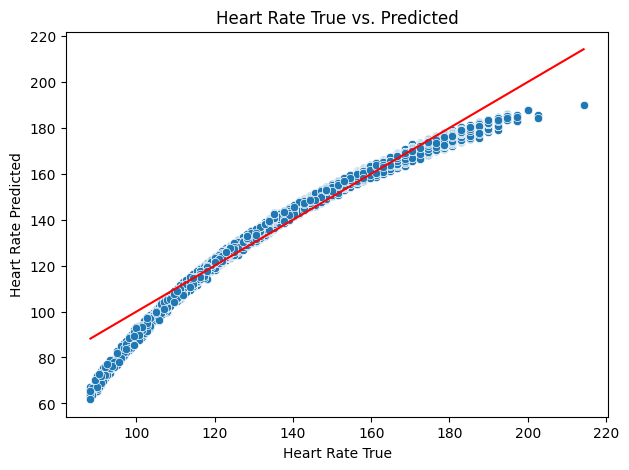

In [ ]:
plt.figure(figsize = (7,5))
sns.scatterplot(x = y_hr_test,
                y = y_hr_test_pred)
plt.plot([y_hr_test.min(), y_hr_test.max()],
         [y_hr_test.min(), y_hr_test.max()],
         color = 'red')
plt.xlabel("Heart Rate True")
plt.ylabel('Heart Rate Predicted')
plt.title('Heart Rate True vs. Predicted')
plt.show()

The heart rate prediction model demonstrated exceptionally strong performance, with an R² value of 0.97, indicating that 97% of the variance in heart rate can be explained by the model's features. The corresponding scatter plot visually confirms this high accuracy, showing a tight clustering of predicted points along the diagonal line of true values. This strong alignment suggests the model is highly reliable for predicting heart rate during exercise.

## **Conclusion**

https://canva.link/2bolcbeb1q8b2jj

The primary objective of this study was to analyze the physiological responses of young athletes during cycloergometer testing and to develop predictive models for power output and heart rate using a range of athletic and test parameters. The results demonstrate that both models offer meaningful insights into exercise performance, with the heart rate model showing particularly strong predictive capability.

The power output model achieved an R² value of 0.73, indicating that approximately 73 percent of the variance in power output can be explained by the selected features. This suggests that the model captures a substantial portion of the underlying relationships between physiological characteristics and power generation. The RMSE of 44.96 watts shows that predictions deviate from actual values by about 45 watts on average, which is acceptable for an initial model but still leaves room for refinement. The MAE of 28.49 watts provides a more intuitive measure of error, indicating that predictions are typically off by around 28.5 watts. In contrast, the MAPE value was extremely high due to the presence of many zero or near-zero power values in the dataset, which makes percentage-based error calculations unreliable. For this reason, metrics such as R², RMSE, and MAE are more appropriate for evaluating the model’s performance.

Visual analysis of the “Power True vs. Power Predicted” scatter plot revealed a generally linear trend, particularly at higher power outputs. However, the model struggled to differentiate between very low power values and zero, resulting in clustering near the origin. This limitation is likely influenced by the large number of zero-power entries in the training data, which may have reduced the model’s ability to capture subtle variations in low-intensity efforts. The positive correlation between weight and average power output appears to be a key factor driving the model’s performance, reflecting the tendency of heavier athletes to generate more power. Minor negative correlations involving BMI and age highlight the complex physiological interactions present in the dataset.

The heart rate prediction model demonstrated substantially stronger performance. With an R² value of 0.97, the model explained 97 percent of the variance in heart rate, indicating exceptional predictive accuracy. The MAE of 3.60 beats per minute shows that predictions were typically within a few beats of the true value, and the MAPE of 2.58 percent confirms consistent accuracy across the full range of heart rate values. The RMSE was 4.62 beats per minute, which aligns with the other strong performance metrics. The corresponding scatter plot showed a tight clustering of points along the diagonal line, further illustrating the model’s reliability. The inclusion of RR interval information likely contributed significantly to this accuracy.

In conclusion, this study successfully developed predictive models for power output and heart rate in young athletes. The heart rate model demonstrated outstanding accuracy and has strong potential for real-time monitoring and personalized training adjustments. The power output model provided meaningful insights into performance factors, although with higher absolute errors. Together, these findings highlight the value of data-driven approaches in understanding physiological responses during exercise and in supporting the design of effective and safe training programs for young athletes.